## 1. BACKGROUND

The rapid advancement of digital technology has encouraged companies across various industries to adopt software solutions in order to improve operational efficiency, workforce productivity, and decision-making quality. One of the fastest-growing business models is **Software as a Service (SaaS)**, a cloud-based software delivery model that operates through subscription services.

The company in this case study is a **Software as a Service (SaaS)** business that provides subscription-based software solutions through the internet. Its product portfolio includes various digital solutions for business needs, such as **Customer Relationship Management (CRM), Marketing Automation, Finance Management, Data Analytics, Support Systems, and Database & Integration Tools**.

The company generates revenue from selling digital products to business customers through subscription plans, licensing models, and additional services. Its customers come from major industries such as finance, manufacturing, retail, energy, insurance, and technology. As the number of transactions and customers continues to grow, the company must ensure that sales growth is aligned with improved profitability.

However, in practice, higher sales volume does not always translate into optimal profit. Factors such as discount strategies, regional performance, product performance, and customer characteristics may significantly influence the company’s profitability. Therefore, sales data analysis is required to understand the overall business condition and identify the key drivers affecting profit performance.

---

## PROBLEM STATEMENT

The company needs to evaluate the current condition of its SaaS sales business, specifically:

1. How is the company’s overall sales and profit performance?
2. What are the sales and profit trends over time?
3. Which regions have the strongest and weakest performance?
4. Which products contribute the most to revenue and profit?
5. Which customers contribute highly or poorly to profitability?
6. Does discounting have a significant impact on company profit?
7. What are the main causes of low business profitability?

---

## ANALYSIS OBJECTIVE

As a Data Analyst, I aim to address these business questions and provide actionable recommendations for stakeholders to support strategic decision-making and profit optimization.

The primary objective of this analysis is **to optimize SaaS Sales profitability**.

---

## BUSINESS VALUE OF THE ANALYSIS

### For the Company

1. Support data-driven business decision-making.
2. Improve pricing and discount strategies.
3. Evaluate product, regional, and customer performance.
4. Increase profitability and operational efficiency.

### For the Management Team

1. Identify business areas that require improvement.
2. Determine growth priorities.
3. Develop expansion and customer retention strategies.

---

## SCOPE OF ANALYSIS

To ensure a focused and structured analysis, the scope is limited to the company’s SaaS sales transaction data, covering:

1. **Business Overview**
   Analysis of total sales, total profit, and total orders.

2. **Time Analysis**
   Analysis of yearly and monthly sales and profit trends.

3. **Regional Analysis**
   Performance comparison across regions (AMER, APJ, EMEA).

4. **Product Analysis**
   Evaluation of each product’s contribution to sales and profit.

5. **Customer Analysis**
   Analysis of customer contribution to revenue and profit.

6. **Discount Analysis**
   Evaluation of the relationship between discounts, profit, and loss levels.

7. **Regression Analysis**
   Testing the impact of Sales, Discount, and Region variables on Profit.

The analysis is conducted based on the available historical data and does not include external factors beyond the dataset.


## 2. DATA PREPARATION

To answer the business questions above, the company’s SaaS sales dataset will be analyzed. The database can be accessed [here](https://www.kaggle.com/datasets/nnthanh101/aws-saas-sales/data).


In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm

This dataset contains SaaS sales transaction data used to analyze business performance based on products, customers, time trends, and profitability. The data consists of SaaS (Software as a Service) product sales transactions, where the unit of analysis is transaction-level data, meaning each row represents one customer purchasing one product.

In [2]:
#step 0: import data
df = pd.read_csv('SaaS-Sales.csv')
df

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,EMEA-2020-110422,1/22/2020,20200122,Dan Allan,Germany,Hamburg,EMEA,EU-WEST,Johnson & Johnson,1055,Healthcare,SMB,SaaS Connector Pack,ETHXMB5TMD,25.2480,3,0.20,4.1028
9990,9991,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,SaaS Connector Pack,LYHOKTRY7L,91.9600,2,0.00,15.6332
9991,9992,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Site Analytics,I5SVMI6M88,258.5760,2,0.20,19.3932
9992,9993,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Support,JHLW4P6LQ2,29.6000,4,0.00,13.3200


DATA COMPONENTS
1. Row ID: A unique identifier for each transaction.
2. Order ID: A unique identifier for each order.
3. Order Date: The date when the order was placed.
4. Date Key: A numerical representation of the order date (YYYYMMDD).
5. Contact Name: The name of the person who placed the order.
6. Country: The country where the order was placed.
7. City: The city where the order was placed.
8. Region: The region where the order was placed.
9. Subregion: The subregion where the order was placed.
10. Customer: The name of the company that placed the order.
11. Customer ID: A unique identifier for each customer.
12. Industry: The industry the customer belongs to.
13. Segment: The customer segment (SMB, Strategic, Enterprise, etc.).
14. Product: The product was ordered.
15. License: The license key for the product.
16. Sales: The total sales amount for the transaction.
17. Quantity: The total number of items in the transaction.
18. Discount: The discount applied to the transaction.
19. Profit: The profit from the transaction.

### DATA UNDERSTANDING

In [3]:
# Step 1: Review the data structure.
print(df.shape)
print(df.dtypes)
print(df.head())

(9994, 19)
Row ID            int64
Order ID            str
Order Date          str
Date Key          int64
Contact Name        str
Country             str
City                str
Region              str
Subregion           str
Customer            str
Customer ID       int64
Industry            str
Segment             str
Product             str
License             str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object
   Row ID          Order ID  Order Date  Date Key    Contact Name  \
0       1  EMEA-2022-152156   11/9/2022  20221109     Nathan Bell   
1       2  EMEA-2022-152156   11/9/2022  20221109     Nathan Bell   
2       3  AMER-2022-138688   6/13/2022  20220613  Deirdre Bailey   
3       4  EMEA-2021-108966  10/11/2021  20211011      Zoe Hodges   
4       5  EMEA-2021-108966  10/11/2021  20211011      Zoe Hodges   

         Country           City Region Subregion           Customer  \
0        Ireland         Dublin  

### DATA CLEANING

In [4]:
# Check for missing values.
print(df.isnull().sum())

Row ID          0
Order ID        0
Order Date      0
Date Key        0
Contact Name    0
Country         0
City            0
Region          0
Subregion       0
Customer        0
Customer ID     0
Industry        0
Segment         0
Product         0
License         0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [5]:
# Check for duplicate records
print(df.duplicated().sum())

0


Overall, the dataset contains no missing values and no duplicate records. The data is already clean, so no missing value treatment is required. The key columns prepared for analysis are as follows: **Sales, Profit, Discount, Quantity, Region, Country, Segment, Industry, Product, License, Customer / Customer ID, and Order Date**.

In [9]:
# Fix tipe data tanggal
df['Order Date'] = pd.to_datetime(df['Order Date'])

This process aims to convert the **Order Date** column into a proper datetime format so it can be processed as time-based data. This enables sales trend analysis over time, allows extraction of **year, month, and quarter**, and supports time series visualization.

In [ ]:
# Time features
df['Year'] = df['Order Date'].dt.year


This process aims to extract the **year** information from transaction dates in order to analyze annual business growth, compare performance across years, and identify long-term trends.

In [ ]:
df['Month'] = df['Order Date'].dt.to_period('M')


This process aims to group transactions into business quarters (**Q1–Q4**) in order to evaluate quarterly performance, identify annual business momentum, and support quarterly sales target strategies.

In [ ]:
df['Quarter'] = df['Order Date'].dt.quarter

This process aims to classify transactions into business quarters (**Q1–Q4**) in order to evaluate quarterly performance, understand annual business momentum, and support quarterly sales target strategies.

In [ ]:
# add profit margin variabel
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

The addition of the **Profit Margin** variable aims to calculate the percentage of profit generated from each transaction. This metric is used to measure sales efficiency, identify whether products or regions are financially healthy or underperforming, and compare profitability more fairly across business segments.

In [10]:
# drop redundant colomn
df = df.drop(columns=['Date Key'], errors='ignore')

This step is performed to remove the **Date Key** column because it is no longer required for the analysis process after the availability of the more informative primary date column, **Order Date**. The **Date Key** column only contains a numeric representation of the date, while the dataset already includes the **Order Date** column. Since both columns store the same time-related information, **Date Key** is considered redundant.

In [95]:
# data validation
num_desc = df.describe()
cat_desc = df.describe(include=['object', 'string'])

This step serves as a final validation of the dataset after the completion of data cleaning and feature engineering processes. The objective is to ensure that the dataset is fully prepared for further analysis.

In [94]:
display(num_desc)
display(cat_desc)

,Row ID,Order Date,Customer ID,Sales,Quantity,Discount,Profit,Year,Quarter,Profit_Margin
count,9994.000000,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2022-05-01 00:07:12.259355,1049.771963,229.858001,3.789574,0.156203,28.656896,2021.722934,2.884130,12.031393
min,1.000000,2020-01-04 00:00:00,1001.000000,0.444000,1.000000,0.000000,-6599.978000,2020.000000,1.000000,-275.000000
25%,2499.250000,2021-05-23 00:00:00,1024.000000,17.280000,2.000000,0.000000,1.728750,2021.000000,2.000000,7.500000
50%,4997.500000,2022-06-27 00:00:00,1049.000000,54.490000,3.000000,0.200000,8.666500,2022.000000,3.000000,27.000000
75%,7495.750000,2023-05-15 00:00:00,1076.000000,209.940000,5.000000,0.200000,29.364000,2023.000000,4.000000,36.250000
max,9994.000000,2023-12-31 00:00:00,1101.000000,22638.480000,14.000000,0.800000,8399.976000,2023.000000,4.000000,50.000000
std,2885.163629,NaN,29.719388,623.245101,2.225110,0.206452,234.260108,1.124039,1.056771,46.675435


,Order ID,Contact Name,Country,City,Region,Subregion,Customer,Industry,Segment,Product,License
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,793,48,262,3,12,99,10,3,14,9994
top,EMEA-2023-100111,Leonard Kelly,United States,London,EMEA,NAMER,Allianz,Finance,SMB,ContactMatcher,16GRM07R1K
freq,14,37,2001,922,4219,2507,192,2127,5191,1842,1


Based on the output, there are negative profit values (**-6,599.978000**), indicating that some transactions generated significant losses. The average profit is relatively low at **28.656896**, suggesting thin profit margins overall. Discounts reach extreme levels of up to **80%**. Sales distribution is highly skewed, meaning most transactions have relatively small values, while a few transactions are exceptionally large.

In [98]:
# Add a flag column: whether the transaction resulted in a loss?
df['Is_Loss'] = df['Profit'] < 0

This step functions as an indicator to identify whether a transaction resulted in a loss or not.

In [97]:
df

,Row ID,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,...,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Profit_Margin,Is_Loss,Discount_Group
0,1,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,...,261.9600,2,0.00,41.9136,2022,2022-11,4,16.00,False,NaN
1,2,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,...,731.9400,3,0.00,219.5820,2022,2022-11,4,30.00,False,NaN
2,3,AMER-2022-138688,2022-06-13,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,...,14.6200,2,0.00,6.8714,2022,2022-06,2,47.00,False,NaN
3,4,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,...,957.5775,5,0.45,-383.0310,2021,2021-10,4,-40.00,True,30-50%
4,5,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,...,22.3680,2,0.20,2.5164,2021,2021-10,4,11.25,False,10-20%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,EMEA-2020-110422,2020-01-22,Dan Allan,Germany,Hamburg,EMEA,EU-WEST,Johnson & Johnson,1055,...,25.2480,3,0.20,4.1028,2020,2020-01,1,16.25,False,10-20%
9990,9991,AMER-2023-121258,2023-02-27,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,...,91.9600,2,0.00,15.6332,2023,2023-02,1,17.00,False,NaN
9991,9992,AMER-2023-121258,2023-02-27,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,...,258.5760,2,0.20,19.3932,2023,2023-02,1,7.50,False,10-20%
9992,9993,AMER-2023-121258,2023-02-27,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,...,29.6000,4,0.00,13.3200,2023,2023-02,1,45.00,False,NaN


In [99]:
# Categorize discount levels.
def discount_category(d):
    if d == 0:
        return 'No Discount'
    elif d <= 0.2:
        return 'Low (≤20%)'
    elif d <= 0.5:
        return 'Medium (21-50%)'
    else:
        return 'High (>50%)'

df['Discount_Category'] = df['Discount'].apply(discount_category)

The **discount_category(d)** function reads each discount value and classifies it into the following categories:

| Discount Value  | Category        |
| --------------- | --------------- |
| 0               | No Discount     |
| 0 < d ≤ 0.20    | Low (≤20%)      |
| 0.21 ≤ d ≤ 0.50 | Medium (21–50%) |
| d > 0.50        | High (>50%)     |


The resulting categories are then assigned to a new column:

In [100]:
df

,Row ID,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,...,Quantity,Discount,Profit,Year,Month,Quarter,Profit_Margin,Is_Loss,Discount_Group,Discount_Category
0,1,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,...,2,0.00,41.9136,2022,2022-11,4,16.00,False,NaN,No Discount
1,2,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,...,3,0.00,219.5820,2022,2022-11,4,30.00,False,NaN,No Discount
2,3,AMER-2022-138688,2022-06-13,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,...,2,0.00,6.8714,2022,2022-06,2,47.00,False,NaN,No Discount
3,4,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,...,5,0.45,-383.0310,2021,2021-10,4,-40.00,True,30-50%,Medium (21-50%)
4,5,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,...,2,0.20,2.5164,2021,2021-10,4,11.25,False,10-20%,Low (≤20%)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,EMEA-2020-110422,2020-01-22,Dan Allan,Germany,Hamburg,EMEA,EU-WEST,Johnson & Johnson,1055,...,3,0.20,4.1028,2020,2020-01,1,16.25,False,10-20%,Low (≤20%)
9990,9991,AMER-2023-121258,2023-02-27,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,...,2,0.00,15.6332,2023,2023-02,1,17.00,False,NaN,No Discount
9991,9992,AMER-2023-121258,2023-02-27,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,...,2,0.20,19.3932,2023,2023-02,1,7.50,False,10-20%,Low (≤20%)
9992,9993,AMER-2023-121258,2023-02-27,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,...,4,0.00,13.3200,2023,2023-02,1,45.00,False,NaN,No Discount


In [34]:
# Verifikasi hasil
print("Shape setelah preparation:", df.shape)
print("\nKolom baru:")
print(df[['Order Date', 'Year', 'Month', 'Quarter', 
          'Profit_Margin', 'Is_Loss', 'Discount_Category']].head(10))

Shape setelah preparation: (9994, 24)

Kolom baru:
  Order Date  Year    Month  Quarter  Profit_Margin  Is_Loss Discount_Category
0 2022-11-09  2022  2022-11        4          16.00    False       No Discount
1 2022-11-09  2022  2022-11        4          30.00    False       No Discount
2 2022-06-13  2022  2022-06        2          47.00    False       No Discount
3 2021-10-11  2021  2021-10        4         -40.00     True   Medium (21-50%)
4 2021-10-11  2021  2021-10        4          11.25    False        Low (≤20%)
5 2020-06-09  2020  2020-06        2          29.00    False       No Discount
6 2020-06-09  2020  2020-06        2          27.00    False       No Discount
7 2020-06-09  2020  2020-06        2          10.00    False        Low (≤20%)
8 2020-06-09  2020  2020-06        2          31.25    False        Low (≤20%)
9 2020-06-09  2020  2020-06        2          30.00    False       No Discount


The **Discount_Category** column is used to simplify discount data into business-friendly groups that are easier to analyze. With this categorization, the company can more effectively evaluate the impact of each discount level on profitability and the risk of loss.

In [35]:
# Check how many transactions resulted in a loss.
loss_count = df['Is_Loss'].sum()
loss_pct = (loss_count / len(df)) * 100
print(f"\nTransaksi rugi: {loss_count} dari {len(df)} ({loss_pct:.1f}%)")


Transaksi rugi: 1871 dari 9994 (18.7%)


Findings show that **18.7% of transactions resulted in a loss**, equivalent to approximately **1 out of every 5 transactions**. This indicates the need for further investigation into why these transactions were unprofitable, including identifying the customers involved, affected products, and regions where the losses occurred.

## EDA

## 3.1 Business Overview

In [21]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()

print(f"Total Sales  : {total_sales:,.0f}")
print(f"Total Profit : {total_profit:,.0f}")
print(f"Total Orders : {total_orders:,}")

Total Sales  : 2,297,201
Total Profit : 286,397
Total Orders : 5,009


In [22]:
profit_margin = (total_profit / total_sales) * 100
avg_order_value = total_sales / total_orders

print("Profit Margin (%):", round(profit_margin, 2))
print("Avg Order Value:", round(avg_order_value, 2))

Profit Margin (%): 12.47
Avg Order Value: 458.61


Total sales reached **2.29 million**, with total profit of **286 thousand**, resulting in a profit margin of approximately **12%**. This indicates that the business remains profitable overall; however, the relatively moderate margin suggests there is pressure on profitability.

## 3.2 Time Analysis

### 3.2.1 Yearly Trend

In [28]:
yearly = df.groupby('Year').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique'),
    Loss_Transactions=('Is_Loss', 'sum')
).reset_index()

yearly['Loss_Rate'] = (
    yearly['Loss_Transactions'] /
    df.groupby('Year')['Is_Loss'].count().values
) * 100

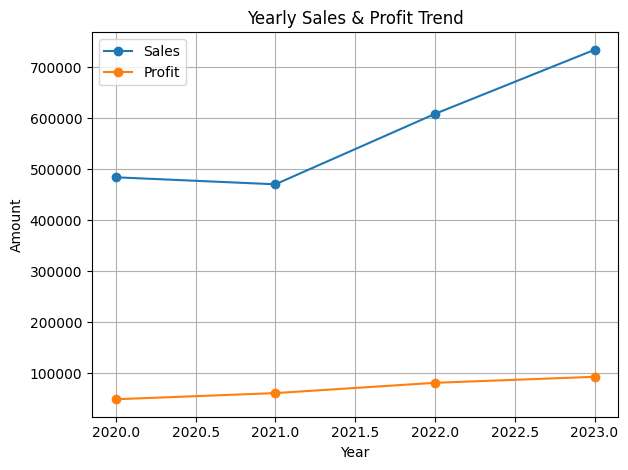

In [29]:
plt.figure()
plt.plot(yearly['Year'], yearly['Total_Sales'], marker='o', label='Sales')
plt.plot(yearly['Year'], yearly['Total_Profit'], marker='o', label='Profit')

plt.title("Yearly Sales & Profit Trend")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

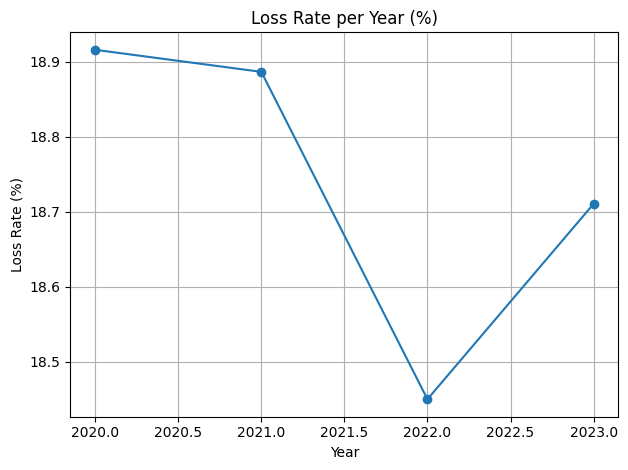

In [30]:
plt.figure()
plt.plot(yearly['Year'], yearly['Loss_Rate'], marker='o')

plt.title("Loss Rate per Year (%)")
plt.xlabel("Year")
plt.ylabel("Loss Rate (%)")
plt.grid()
plt.tight_layout()
plt.show()

**Figure 1** shows a decline in sales in 2021, while profit continued to increase, indicating improved efficiency or reduced discounting during that period. Afterward, the business demonstrated consistent growth in both sales and profit through 2023.

**Figure 2** shows that the proportion of loss-making transactions declined in 2022, reflecting improved operational efficiency or a more effective pricing strategy. However, the increase again in 2023 indicates potential higher discounting levels or renewed pressure on profitability.

### 3.2.2 Monthly Trend

In [24]:
monthly = df.groupby('Month').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

monthly['Month'] = monthly['Month'].dt.to_timestamp()

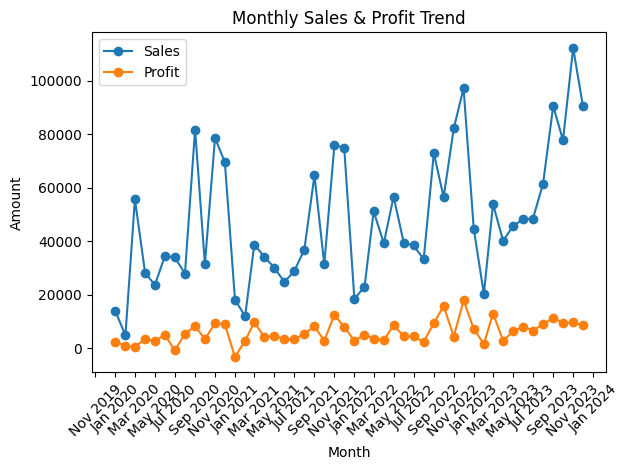

In [25]:
import matplotlib.dates as mdates

fig, ax = plt.subplots()

ax.plot(monthly['Month'], monthly['Total_Sales'], marker='o', label='Sales')
ax.plot(monthly['Month'], monthly['Total_Profit'], marker='o', label='Profit')

ax.set_title("Monthly Sales & Profit Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Amount")

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**Figure 1** shows that overall sales increased over time. The highest surge occurred in 2023, where profit followed the upward sales trend, although not always proportionally.

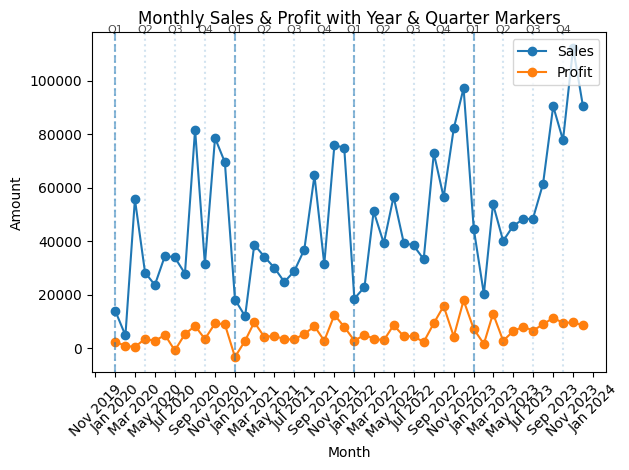

In [37]:
fig, ax = plt.subplots()

# Plot utama
ax.plot(monthly['Month'], monthly['Total_Sales'], marker='o', label='Sales')
ax.plot(monthly['Month'], monthly['Total_Profit'], marker='o', label='Profit')

# --- Garis Tahun ---
for year in monthly['Month'].dt.year.unique():
    ax.axvline(pd.Timestamp(f'{year}-01-01'), linestyle='--', alpha=0.5)

# --- Garis Quarter ---
for date in monthly['Month']:
    if date.month in [1, 4, 7, 10]:
        ax.axvline(date, linestyle=':', alpha=0.2)

# --- Label Q1 Q2 Q3 Q4 ---
quarters = {
    1: 'Q1',
    4: 'Q2',
    7: 'Q3',
    10: 'Q4'
}

for date in monthly['Month']:
    if date.month in quarters:
        ax.text(
            date,
            monthly['Total_Sales'].max() * 1.05,  # posisi di atas grafik
            quarters[date.month],
            ha='center',
            fontsize=8,
            alpha=0.7
        )

# --- Format Axis ---
ax.set_title("Monthly Sales & Profit with Year & Quarter Markers")
ax.set_xlabel("Month")
ax.set_ylabel("Amount")

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**Figure 2** shows a consistent seasonal pattern, where business performance tends to improve in the later quarters (**Q3–Q4**). However, this growth is not always accompanied by proportional profit increases, indicating a reliance on promotional or discount strategies that may pressure margins.

There was also an anomalous period in early 2021, marked by a significant decline in sales accompanied by negative profit, indicating the occurrence of loss-making transactions.

## 3.3 Regional Analysis

In [38]:
region = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

# Tambahkan Profit Margin
region['Profit_Margin'] = (region['Total_Profit'] / region['Total_Sales']) * 100

region.sort_values(by='Total_Sales', ascending=False)

,Region,Total_Sales,Total_Profit,Total_Orders,Profit_Margin
2,EMEA,1.043887e+06,147456.0450,2098,14.125671
0,AMER,8.378496e+05,127426.9898,1842,15.208814
1,APJ,4.154642e+05,11513.9869,1069,2.771354


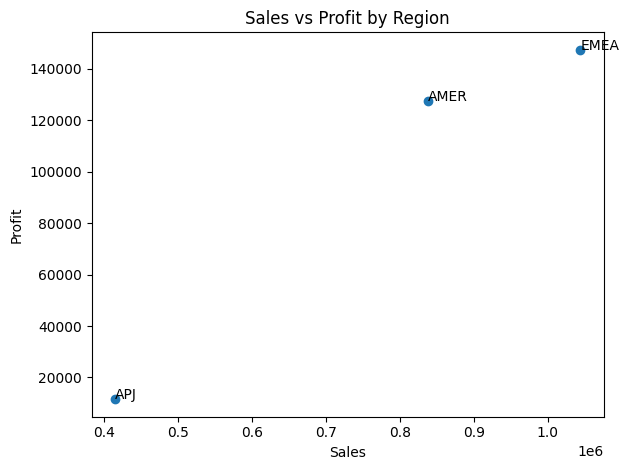

In [41]:
plt.figure()

plt.scatter(region['Total_Sales'], region['Total_Profit'])

for i in range(len(region)):
    plt.text(region['Total_Sales'][i], 
             region['Total_Profit'][i], 
             region['Region'][i])

plt.title("Sales vs Profit by Region")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

**Figure 1** shows that **EMEA** is the best-performing region, generating the highest sales and profit simultaneously. **AMER** demonstrates strong efficiency, with the ability to generate relatively high profit compared to its sales level. **APJ** shows significantly weaker performance in both sales and profit, indicating that the region not only contributes less overall but also operates less efficiently.

The underperformance of **APJ** suggests potential structural issues, such as suboptimal pricing strategies or higher operating costs compared to other regions.

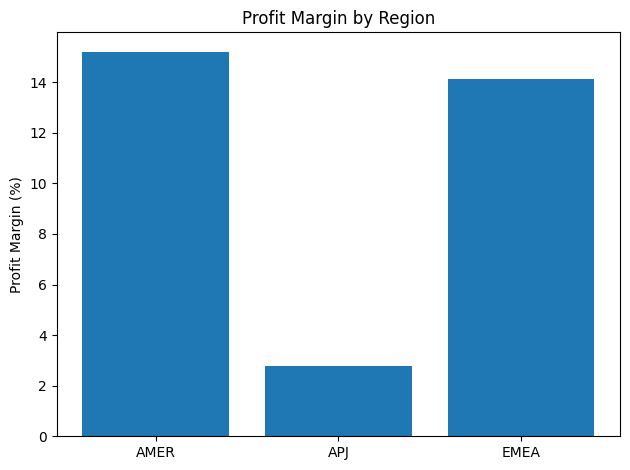

In [42]:
plt.figure()
plt.bar(region['Region'], region['Profit_Margin'])

plt.title("Profit Margin by Region")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

**Figure 2** shows a significant performance gap across regions, where **EMEA** and **AMER** make strong contributions to revenue and profit, while **APJ** lags far behind and may represent a source of inefficiency within the business.

In [66]:
region_detail = df.groupby(['Region', 'Discount_Group']).agg(
    Avg_Profit=('Profit', 'mean')
).reset_index()

region_detail

,Region,Discount_Group,Avg_Profit
0,AMER,0-10%,106.564728
1,AMER,10-20%,33.323354
2,AMER,20-30%,-28.025792
3,AMER,30-50%,-103.430020
4,AMER,50%+,-136.217291
5,APJ,10-20%,16.833516
6,APJ,20-30%,-45.842799
7,APJ,30-50%,-161.512514
8,APJ,50%+,-83.296106
9,EMEA,0-10%,93.565946


In the **AMER** and **EMEA** regions, the company remains profitable at discount levels of **10–20%**. In contrast, the **APJ** region only generates profit at discount levels of **0–10%**, and becomes unprofitable when higher discounts are applied.

This provides further evidence that **APJ’s low margins are driven not by the region itself, but by discounting practices**.

## 3.4 Product Analysis

In [43]:
product = df.groupby('Product').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

product['Profit_Margin'] = (product['Total_Profit'] / product['Total_Sales']) * 100

product = product.sort_values(by='Total_Sales', ascending=False)
product.head()

,Product,Total_Sales,Total_Profit,Total_Orders,Profit_Margin
3,ContactMatcher,410378.265,12496.2822,1552,3.045064
5,FinanceHub,340935.415,32136.4203,886,9.425955
11,Site Analytics,330007.054,44515.7306,814,13.489327
7,Marketing Suite - Gold,223843.608,21278.8264,777,9.506113
1,Big Ol Database,189238.631,3384.7569,112,1.788618


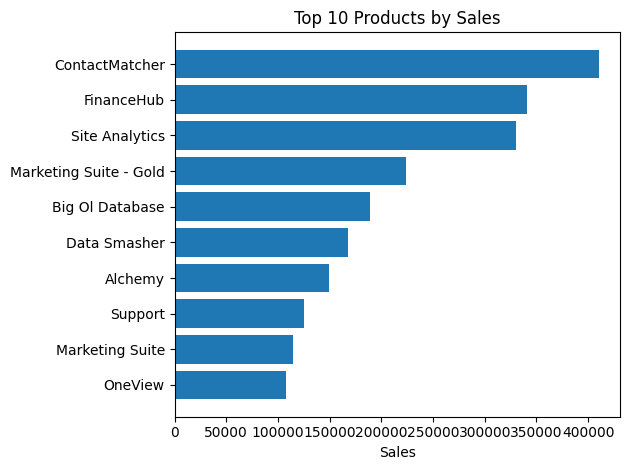

In [44]:
top_sales = product.head(10)

plt.figure()
plt.barh(top_sales['Product'], top_sales['Total_Sales'])

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

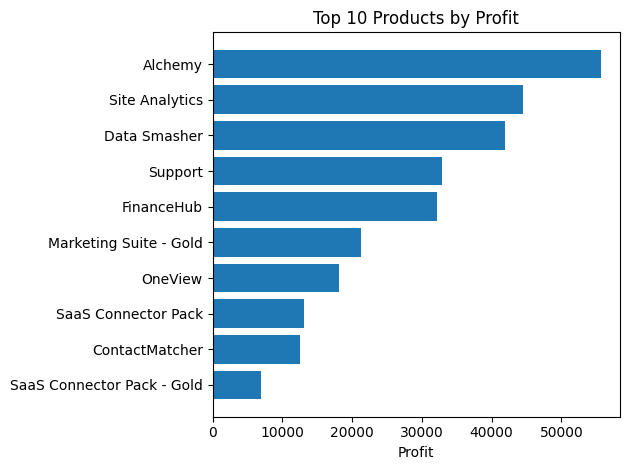

In [45]:
top_profit = product.sort_values(by='Total_Profit', ascending=False).head(10)

plt.figure()
plt.barh(top_profit['Product'], top_profit['Total_Profit'])

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Figures 1 and 2** show that **ContactMatcher** has the highest sales, yet records the second-lowest profit. **Site Analytics** ranks as the third-highest in sales and delivers the second-highest profit.

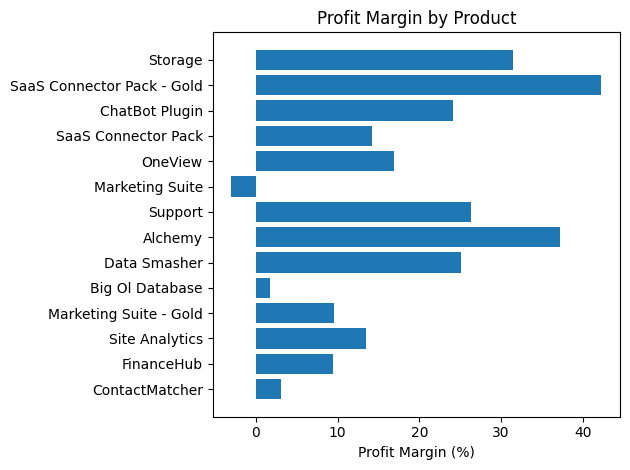

In [46]:
plt.figure()
plt.barh(product['Product'], product['Profit_Margin'])

plt.title("Profit Margin by Product")
plt.xlabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

**Figure 3** shows that products such as **SaaS Connector Pack - Gold** and **Alchemy** demonstrate high efficiency with strong profit margins, making them prime candidates for scaling strategies.

However, several products show inefficient performance, such as **Marketing Suite**, which generates losses, as well as products with low margins despite high sales volumes, indicating pressure on profitability.

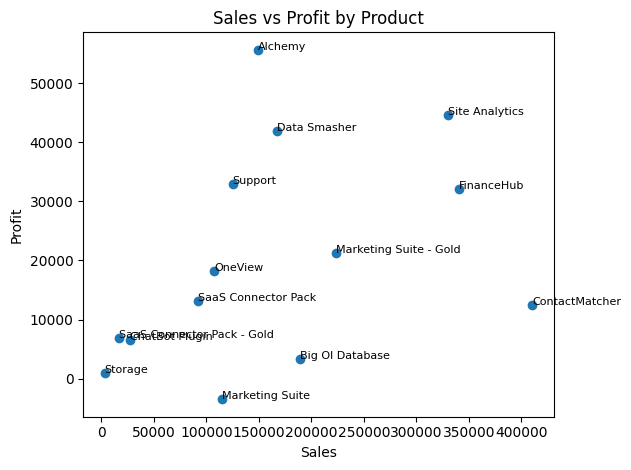

In [47]:
plt.figure()

plt.scatter(product['Total_Sales'], product['Total_Profit'])

for i in range(len(product)):
    plt.text(product['Total_Sales'][i],
             product['Total_Profit'][i],
             product['Product'][i],
             fontsize=8)

plt.title("Sales vs Profit by Product")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

**Figure 4** shows that products such as **Site Analytics** and **Finance Hub** are ideal, as they contribute strong and optimal profit performance. Products generating losses, such as **Marketing Suite**, require further evaluation.

## 3.5 Customer Analysis

In [48]:
customer = df.groupby('Customer').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

customer['Profit_Margin'] = (customer['Total_Profit'] / customer['Total_Sales']) * 100
customer['Avg_Order_Value'] = customer['Total_Sales'] / customer['Total_Orders']

customer = customer.sort_values(by='Total_Sales', ascending=False)
customer.head()

,Customer,Total_Sales,Total_Profit,Total_Orders,Profit_Margin,Avg_Order_Value
10,Anthem,55719.2100,5953.2038,58,10.684293,960.676034
38,Ford Motor,43893.0424,4010.7662,103,9.137590,426.146043
4,Allianz,42904.1670,5531.8834,102,12.893581,420.629088
16,Bank of America Corp.,41255.9471,6449.8554,65,15.633759,634.706878
92,Valero Energy,41220.4188,10308.6297,58,25.008552,710.696876


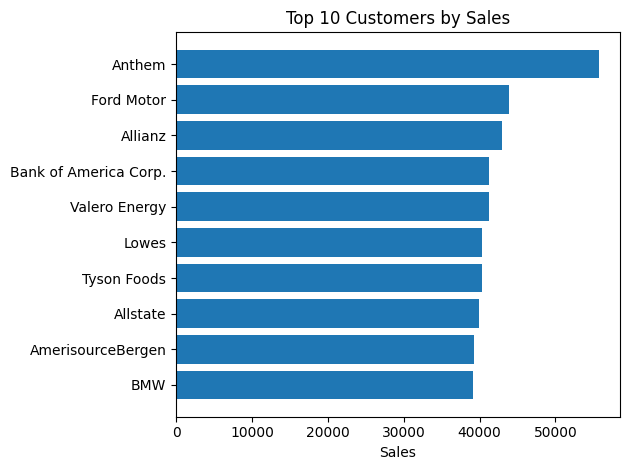

In [49]:
top_sales = customer.head(10)

plt.figure()
plt.barh(top_sales['Customer'], top_sales['Total_Sales'])
plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

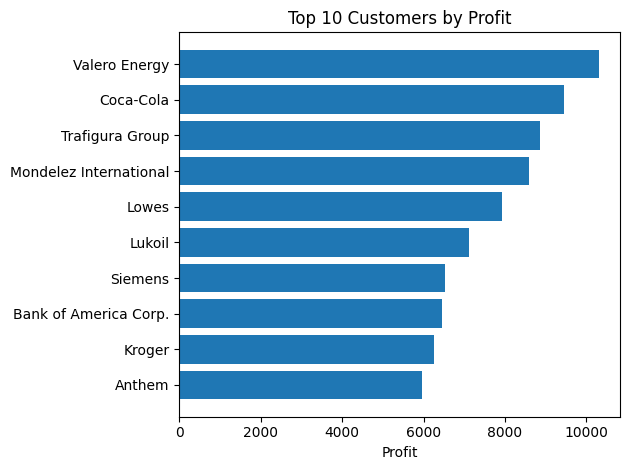

In [50]:
top_profit = customer.sort_values(by='Total_Profit', ascending=False).head(10)

plt.figure()
plt.barh(top_profit['Customer'], top_profit['Total_Profit'])
plt.title("Top 10 Customers by Profit")
plt.xlabel("Profit")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Not all customers with high sales contributions generate optimal profit. Some customers act as **revenue drivers**, but not necessarily as primary **profit drivers**.

**Figures 1 and 2** show that **Valero** is among the top five buyers and contributes one of the highest profit values in SaaS Sales. **Lowes** is also ranked among the top ten buyers.

There is a group of high-value customers that make significant contributions to both revenue and profit, making them top priorities for retention and growth strategies, such as **Valero Energy, Coca-Cola, Trafigura, and Mondelez**.

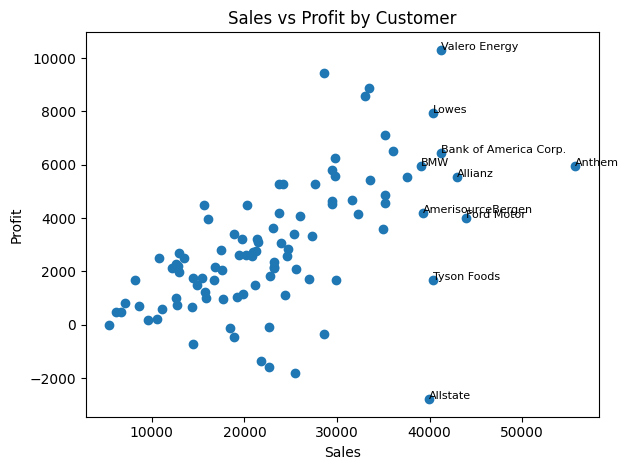

In [51]:
plt.figure()

plt.scatter(customer['Total_Sales'], customer['Total_Profit'])

# label hanya top 10 biar tidak ramai
for i in range(10):
    plt.text(top_sales['Total_Sales'].iloc[i],
             top_sales['Total_Profit'].iloc[i],
             top_sales['Customer'].iloc[i],
             fontsize=8)

plt.title("Sales vs Profit by Customer")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

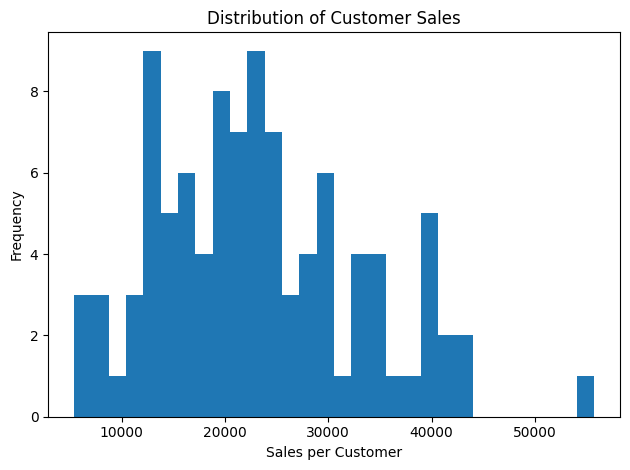

In [52]:
plt.figure()
plt.hist(customer['Total_Sales'], bins=30)
plt.title("Distribution of Customer Sales")
plt.xlabel("Sales per Customer")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [53]:
top_10_sales = top_sales['Total_Sales'].sum()
total_sales = customer['Total_Sales'].sum()

print("Contribution Top 10 Customers (%):", round((top_10_sales / total_sales) * 100, 2))

Contribution Top 10 Customers (%): 18.45


**Figure 4** shows that many customers fall within the low to medium sales range, while only a small number of customers contribute the majority of total revenue. **Allstate** is the customer contributing the highest loss.

## 3.6 Discount Analysis

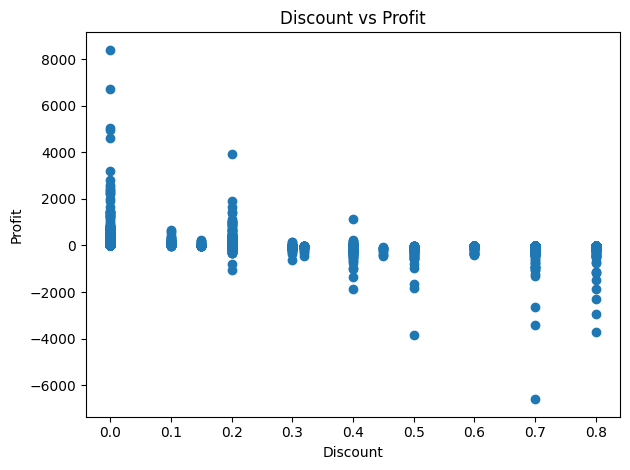

In [54]:
plt.figure()

plt.scatter(df['Discount'], df['Profit'])

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

As discount levels increase, profit declines. There is a negative relationship between discount rates and profit, where higher discounts lead to lower profit generation.

In [55]:
df['Discount_Group'] = pd.cut(
    df['Discount'],
    bins=[0, 0.1, 0.2, 0.3, 0.5, 1],
    labels=['0-10%', '10-20%', '20-30%', '30-50%', '50%+']
)

In [56]:
discount_analysis = df.groupby('Discount_Group').agg(
    Avg_Sales=('Sales', 'mean'),
    Avg_Profit=('Profit', 'mean'),
    Total_Orders=('Order ID', 'count')
).reset_index()

discount_analysis

,Discount_Group,Avg_Sales,Avg_Profit,Total_Orders
0,0-10%,578.397351,96.055074,94
1,10-20%,213.575867,24.738824,3709
2,20-30%,454.742974,-45.679636,227
3,30-50%,630.047603,-156.282991,310
4,50%+,75.033572,-89.438144,856


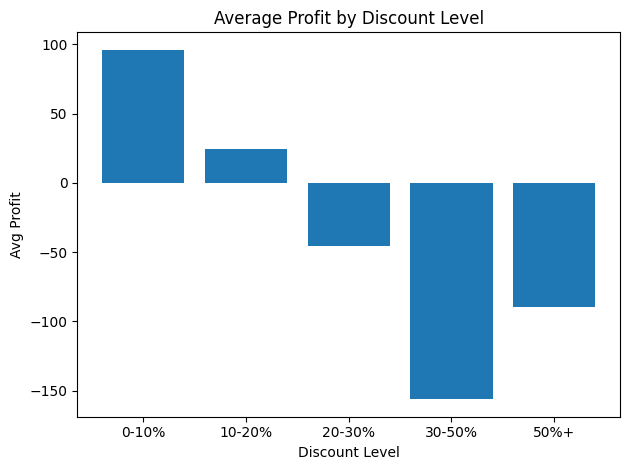

In [57]:
plt.figure()
plt.bar(discount_analysis['Discount_Group'], discount_analysis['Avg_Profit'])

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount Level")
plt.ylabel("Avg Profit")
plt.tight_layout()
plt.show()

The average profit by discount level shows that at the **20–30% discount range**, the company experiences a negative average profit. Transactions with higher discount levels also show greater loss rates, indicating that discounting is a key factor putting pressure on profitability.

In [60]:
df['Is_Loss'] = df['Profit'] < 0

loss_discount = df.groupby('Discount_Group').agg(
    Loss_Rate=('Is_Loss', 'mean')
).reset_index()

loss_discount['Loss_Rate'] = loss_discount['Loss_Rate'] * 100
loss_discount['Loss_Rate']

0      4.255319
1     13.992990
2     91.629956
3     91.612903
4    100.000000
Name: Loss_Rate, dtype: float64

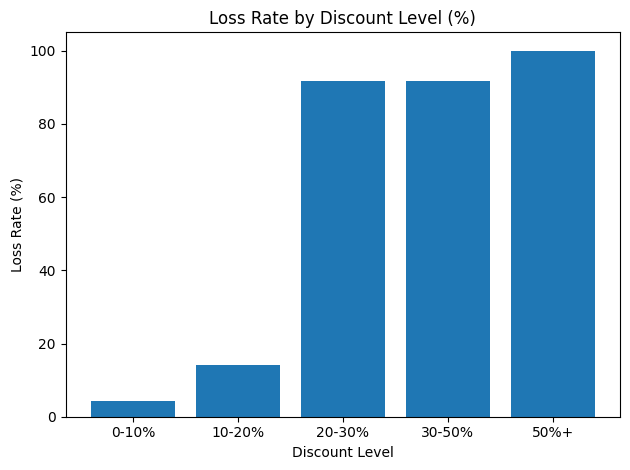

In [59]:
plt.figure()
plt.bar(loss_discount['Discount_Group'], loss_discount['Loss_Rate'])

plt.title("Loss Rate by Discount Level (%)")
plt.xlabel("Discount Level")
plt.ylabel("Loss Rate (%)")
plt.tight_layout()
plt.show()

There appears to be a discount threshold at which profit begins to decline significantly, indicating the need for stronger discount control policies. In the **Loss Rate by Discount Level** visualization, the probability of loss increases as discount levels rise. The most significant spike in loss rate occurs within the **20–30% discount range**.

## 3.7 Deep Dive

In [69]:
#1. Discount vs Profit per Product

product_discount = df.groupby(['Product', 'Discount_Group']).agg(
    Avg_Profit=('Profit', 'mean')
).reset_index()

product_discount

,Product,Discount_Group,Avg_Profit
0,Alchemy,10-20%,483.208508
1,Alchemy,30-50%,242.552800
2,Big Ol Database,0-10%,416.042150
3,Big Ol Database,10-20%,160.329110
4,Big Ol Database,20-30%,65.207900
5,Big Ol Database,30-50%,-412.082900
6,Big Ol Database,50%+,-851.274743
7,ChatBot Plugin,10-20%,3.849619
8,ContactMatcher,10-20%,45.208464
9,ContactMatcher,20-30%,-63.006067


Discount analysis shows several products become unprofitable beyond 20–30% discount levels, particularly Big Ol Database and Marketing Suite. Meanwhile, Alchemy remained profitable even under higher discounts, indicating stronger pricing resilience. A differentiated discount strategy by product is recommended instead of blanket promotions.

In [68]:
#2. Discount vs Profit per Region

region_discount = df.groupby(['Region', 'Discount_Group']).agg(
    Avg_Profit=('Profit', 'mean')
).reset_index()

region_discount

,Region,Discount_Group,Avg_Profit
0,AMER,0-10%,106.564728
1,AMER,10-20%,33.323354
2,AMER,20-30%,-28.025792
3,AMER,30-50%,-103.430020
4,AMER,50%+,-136.217291
5,APJ,10-20%,16.833516
6,APJ,20-30%,-45.842799
7,APJ,30-50%,-161.512514
8,APJ,50%+,-83.296106
9,EMEA,0-10%,93.565946


In [70]:
#3. Discount vs Profit per Customer
customer_discount = df.groupby(['Customer', 'Discount_Group']).agg(
    Avg_Profit=('Profit', 'mean')
).reset_index()

customer_discount

,Customer,Discount_Group,Avg_Profit
0,AT&T,0-10%,64.179300
1,AT&T,10-20%,23.037031
2,AT&T,30-50%,-131.851900
3,AT&T,50%+,-112.209843
4,Abbott Laboratories,0-10%,18.460400
...,...,...,...
428,Wells Fargo,0-10%,252.931550
429,Wells Fargo,10-20%,14.198391
430,Wells Fargo,20-30%,-54.725633
431,Wells Fargo,30-50%,-40.440857


Customer-level discount analysis shows several strategic accounts become unprofitable when discounts exceed 20–30%. For example, Wells Fargo and AT&T generated positive profits at lower discount tiers but turned loss-making under aggressive pricing. This suggests the need for account-based pricing discipline rather than uniform discounting.

In [71]:
#4. Validasi hubungan Diskon dan Profit

df[['Discount', 'Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


A correlation value of **-0.2** indicates a negative relationship, meaning the variables move in opposite directions. There is a negative relationship between discount and profit, where increasing discount levels tend to reduce profit, although the linear correlation is relatively weak.

In [74]:
discount_analysis = df.groupby('Discount_Group').agg(
    Avg_Profit=('Profit', 'mean'),
    Loss_Rate=('Is_Loss', 'mean')
).reset_index()

discount_analysis['Loss_Rate'] *= 100
discount_analysis

,Discount_Group,Avg_Profit,Loss_Rate
0,0-10%,96.055074,4.255319
1,10-20%,24.738824,13.992990
2,20-30%,-45.679636,91.629956
3,30-50%,-156.282991,91.612903
4,50%+,-89.438144,100.000000


In [75]:
#5 validasi region APJ

region_discount = df.groupby(['Region', 'Discount_Group']).agg(
    Avg_Profit=('Profit', 'mean')
).reset_index()

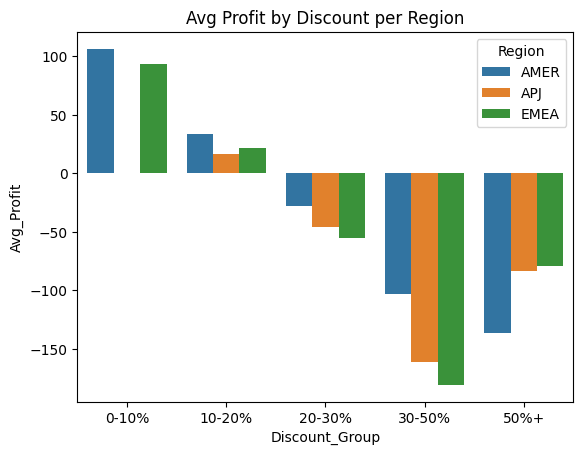

In [76]:
plt.figure()
sns.barplot(
    data=region_discount,
    x='Discount_Group',
    y='Avg_Profit',
    hue='Region'
)

plt.title("Avg Profit by Discount per Region")
plt.show()

All regions experience declining profit as discount levels increase, but **APJ** shows the fastest decline, while **EMEA** suffers the most severe losses at high discount levels.

It can be concluded that the primary issue in this business does not lie in sales performance, but rather in a suboptimal discount strategy, which significantly pressures profitability across multiple business dimensions.

## 3.8 Analisis Regresi

In [92]:
# pilih variabel
df_reg = df[['Profit', 'Sales', 'Discount', 'Region']].copy()

# encoding
df_reg = pd.get_dummies(df_reg, drop_first=True)

# define X dan y
X = df_reg.drop('Profit', axis=1)
y = df_reg['Profit']

X = sm.add_constant(X)
X = X.astype(float)

# fit model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.272
Method:                 Least Squares   F-statistic:                     935.1
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:56:02   Log-Likelihood:                -67123.
No. Observations:                9994   AIC:                         1.343e+05
Df Residuals:                    9989   BIC:                         1.343e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          20.4521      3.563      5.740      

* Based on the regression analysis, the **F-statistic significance value (0.00 < 0.05)** indicates that profit is significantly influenced by the variables included in the model.
* The **Sales** and **Discount** variables have a significant effect on profit, as their **p-values (0.00 < 0.05)** indicate statistical significance.
* The **Discount** variable has a significant negative effect on profit, showing that increasing discount levels consistently reduce profitability.
* **Sales** has a significant positive effect on profit, indicating that higher sales directly contribute to increased profit.
* There are performance differences across regions, where the **APJ** region shows lower profitability compared to **AMER**.
* The model explains approximately **31% of the variation in profit**, indicating that although the selected variables are significant, other factors still influence profitability.

## 4. Simulation

From the entire analysis process, I conclude that the company’s main challenge does not lie in sales performance, but rather in discount management and pricing strategy. Below are several recommendation scenarios based on the findings:

1. **Discount Policy Implementation**
   Establish a maximum discount cap (**<20%**) to protect profitability.

2. **High-Discount Transaction Review**
   Evaluate transactions with high discount levels that have the potential to generate losses.

3. **Develop a More Adaptive Pricing Strategy Based On:**

* Product
* Region
* Customer Segment

### Simulation 1: Discount Policy Implementation

Establish a maximum discount cap (**<20%**) to maintain profitability.

In [102]:
df_sim1 = df.copy()

# cap discount max 20%
df_sim1['New_Discount'] = df_sim1['Discount'].clip(upper=0.2)

# selisih discount yang berhasil dikurangi
df_sim1['Recovered_Discount'] = df_sim1['Discount'] - df_sim1['New_Discount']

# simulasi profit baru
df_sim1['New_Profit'] = df_sim1['Profit'] + (
    df_sim1['Sales'] * df_sim1['Recovered_Discount']
)

# hasil
old_profit = df['Profit'].sum()
new_profit = df_sim1['New_Profit'].sum()

increase = new_profit - old_profit
increase_pct = (increase / old_profit) * 100

print("Profit Lama      :", round(old_profit,2))
print("Profit Baru      :", round(new_profit,2))
print("Peningkatan Profit :", round(increase,2))
print("Peningkatan (%)  :", round(increase_pct,2), "%")

Profit Lama      : 286397.02
Profit Baru      : 373935.54
Peningkatan Profit : 87538.52
Peningkatan (%)  : 30.57 %


### Simulation 2: High-Discount Transaction Review

Transactions with discounts above **50%** are removed or rejected.

In [103]:
df_sim2 = df[df['Discount'] <= 0.5]

print("Profit Lama :", df['Profit'].sum())
print("Profit Baru :", df_sim2['Profit'].sum())
print("Jumlah transaksi tersisa:", len(df_sim2))

Profit Lama : 286397.0217
Profit Baru : 362956.073
Jumlah transaksi tersisa: 9138


### Simulation 3: Adaptive Pricing Based on Region

Different pricing strategies across regions have the potential to increase profit without reducing overall sales volume.

In [104]:
df_sim3 = df.copy()

def region_discount(row):
    if row['Region'] == 'APJ':
        return min(row['Discount'], 0.10)
    elif row['Region'] == 'AMER':
        return min(row['Discount'], 0.20)
    else:
        return min(row['Discount'], 0.25)

df_sim3['New_Discount'] = df_sim3.apply(region_discount, axis=1)

df_sim3['Recovered_Discount'] = df_sim3['Discount'] - df_sim3['New_Discount']

df_sim3['New_Profit'] = df_sim3['Profit'] + (df_sim3['Sales'] * df_sim3['Recovered_Discount'])

print("Profit Lama :", df['Profit'].sum())
print("Profit Baru :", df_sim3['New_Profit'].sum())

Profit Lama : 286397.0217
Profit Baru : 391250.457236


Compare all simulation scenarios to identify the most profitable outcome.

In [108]:
results = pd.DataFrame({
    'Scenario': ['Current', 'Cap 20%', 'Remove >50%', 'Adaptive Region'],
    'Profit': [
        df['Profit'].sum(),
        df_sim1['New_Profit'].sum(),
        df_sim2['Profit'].sum(),
        df_sim3['New_Profit'].sum()
    ]
})

# Profit baseline
base_profit = results.loc[0, 'Profit']

# Selisih profit nominal
results['Increase'] = results['Profit'] - base_profit

# Persentase peningkatan profit vs kondisi saat ini
results['Increase_%'] = ((results['Increase'] / base_profit) * 100).round(2)

# Profit sebagai persentase terhadap baseline
results['Profit_%_of_Current'] = ((results['Profit'] / base_profit) * 100).round(2)

results

,Scenario,Profit,Increase,Increase_%,Profit_%_of_Current
0,Current,286397.021700,0.000000,0.00,100.00
1,Cap 20%,373935.539156,87538.517456,30.57,130.57
2,Remove >50%,362956.073000,76559.051300,26.73,126.73
3,Adaptive Region,391250.457236,104853.435536,36.61,136.61


Based on the pricing policy simulations, the company has the opportunity to increase profit by up to **36.6%** without increasing sales volume. The most effective strategy is implementing **adaptive discounting based on region**, followed by a **maximum discount cap of 20%**, and eliminating discounts above **50%**.

# 5. FINAL CONCLUSION OF SaaS SALES DATA ANALYSIS PROJECT

1. Based on the SaaS company sales data analysis, it can be concluded that the company has shown **positive business growth**, reflected in total sales of **2.29 million**, total profit of **286 thousand**, and a total of **5,009 orders**. This indicates that the company has an active market and solid product demand.

2. From a time-based perspective, business performance showed an upward trend year over year, especially during **2022 to 2023**. Sales and profit grew consistently, indicating business expansion and increased customer acquisition. However, sales growth has not been fully matched by profitability efficiency.

3. In the regional analysis, significant performance differences were identified across regions. **EMEA** and **AMER** showed relatively strong contributions to both sales and profit, while **APJ** demonstrated lower profitability. This suggests the need to review sales and pricing strategies in underperforming regions.

4. From a product perspective, several products were identified as major revenue drivers, but not all products generated healthy profit margins. Some products produced low or even negative profit, indicating the need for portfolio evaluation, pricing adjustments, and bundling strategies.

5. In the customer analysis, a relatively small number of customers contributed a large share of total revenue. However, not all high-value customers generated optimal profit. Some customers with high sales values delivered low profit due to heavy discounting or thin margins.

6. The most important finding of this project is that **discounting is the primary factor pressuring company profitability**. The analysis shows a negative relationship between discount and profit. When discounts exceed **20%**, average profit begins to turn negative and the number of loss-making transactions rises sharply. At discount levels above **50%**, nearly all transactions result in losses.

7. The regression analysis further supports this finding, where the **Discount** variable has a statistically significant negative impact on **Profit**, while **Sales** has a positive effect. This means the company has the ability to generate profit through sales, but an uncontrolled discount strategy is reducing its profit potential.

8. Business policy simulations show that the company has opportunities to increase profit **without increasing sales volume**, through improvements in pricing strategy:

* A maximum discount cap of **20%** could increase profit by **30.57%**
* Eliminating extreme discount transactions (**>50%**) could increase profit by **26.73%**
* An adaptive discount strategy based on region could increase profit by **36.61%** (**best scenario**)

---

## Key Conclusion

The company’s main issue does not lie in weak sales performance, but in a **suboptimal discount and pricing strategy**. With tighter discount controls, region-based pricing adjustments, and evaluation of underperforming customers and products, the company has strong potential to significantly improve profitability without relying solely on sales growth.

---

## Strategic Recommendations

1. Implement an adaptive discount strategy based on region.
2. Apply a maximum discount cap of **20%**.
3. Eliminate extreme discount transactions (**>50%**).

---

## Closing Statement

Overall, the company has a strong business foundation and substantial growth potential. The key priority going forward is to transform sales growth into sustainable profit growth through smarter, data-driven pricing strategies.

In [112]:
df.head()


,Row ID,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,...,Quantity,Discount,Profit,Year,Month,Quarter,Profit_Margin,Is_Loss,Discount_Group,Discount_Category
0,1,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,...,2,0.00,41.9136,2022,2022-11,4,16.00,False,NaN,No Discount
1,2,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,...,3,0.00,219.5820,2022,2022-11,4,30.00,False,NaN,No Discount
2,3,AMER-2022-138688,2022-06-13,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,...,2,0.00,6.8714,2022,2022-06,2,47.00,False,NaN,No Discount
3,4,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,...,5,0.45,-383.0310,2021,2021-10,4,-40.00,True,30-50%,Medium (21-50%)
4,5,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,...,2,0.20,2.5164,2021,2021-10,4,11.25,False,10-20%,Low (≤20%)


In [113]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Contact Name', 'Country', 'City', 'Region', 'Subregion', 'Customer', 'Customer ID', 'Industry', 'Segment', 'Product', 'License', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Quarter', 'Profit_Margin', 'Is_Loss', 'Discount_Group', 'Discount_Category']


In [115]:
df.to_excel("saas_sales_tableau.xlsx", index=False)